# ✋ Sign Language Recognition Using Deep Learning

## Final Deep Learning Project

| Information | Details |
|---|---|
| Student Name | Minal Daryn |
| Project Title | Sign Language Recognition Using Deep Learning |
| Course | Deep Learning |
| Project Type | Computer Vision / Image Classification |
| Desired Grade | 100 / A |

This project builds a CNN model to recognize American Sign Language hand gestures from images.

In [1]:
# 📦 Import all required libraries for the project

import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📌 Project Overview

This project focuses on building an artificial intelligence system capable of recognizing American Sign Language hand gestures.

The project uses:

- Deep Learning
- Computer Vision
- CNN model
- Image Classification
- Streamlit application

The project also has social importance because sign language recognition can support accessibility and communication.

In [2]:
# 📥 Install Kaggle library to download the dataset

!pip install kaggle -q

In [3]:
# 🔑 Upload kaggle.json API file

from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darynminal","key":"6b38091e2cb8901c5eb56442ea926569"}'}

In [4]:
# ⚙ Configure Kaggle API key

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("kaggle.json"):
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key is ready.")

Kaggle API key is ready.


In [5]:
# 📥 Download ASL Alphabet dataset from Kaggle

!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:11<00:00, 96.6MB/s]



In [6]:
# 📂 Extract downloaded ZIP dataset

zip_path = "/content/asl-alphabet.zip"
extract_path = "/content/asl_alphabet"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
# 📁 Set path to training dataset folder

train_dir = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"

# ✅ Check if dataset folder exists
print("Dataset exists:", os.path.exists(train_dir))

# 👀 Show first 10 class folders
print("Sample classes:", os.listdir(train_dir)[:10])

Dataset exists: True
Sample classes: ['F', 'C', 'H', 'L', 'Q', 'W', 'T', 'U', 'P', 'V']


# 📂 Dataset Information

Dataset: ASL Alphabet Dataset  
Source: Kaggle  
Author: grassknoted  

The dataset contains 29 classes:

- A–Z letters
- del
- nothing
- space

This is a multi-class image classification problem.

In [17]:
# ⚙ Define basic image training settings

img_size = 128          # Image size will be 64x64
batch_size = 32        # Number of images per batch
num_classes = 29       # ASL dataset has 29 classes

In [9]:
# 🔄 Create image preprocessing and augmentation settings

train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values from 0-255 to 0-1
    validation_split=0.2,        # Use 20% of data for validation
    rotation_range=15,           # Random rotation
    zoom_range=0.15,             # Random zoom
    width_shift_range=0.1,       # Horizontal shift
    height_shift_range=0.1,      # Vertical shift
    brightness_range=[0.8, 1.2]  # Brightness variation
)

In [10]:
# 📚 Create training data generator

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),   # Resize images to 64x64
    batch_size=batch_size,
    class_mode="categorical",           # Multi-class classification
    subset="training",
    shuffle=True
)

# 📚 Create validation data generator

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [11]:
# 📊 Show dataset statistics

class_names = list(train_generator.class_indices.keys())

print("Number of training images:", train_generator.samples)
print("Number of validation images:", validation_generator.samples)
print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of training images: 69600
Number of validation images: 17400
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


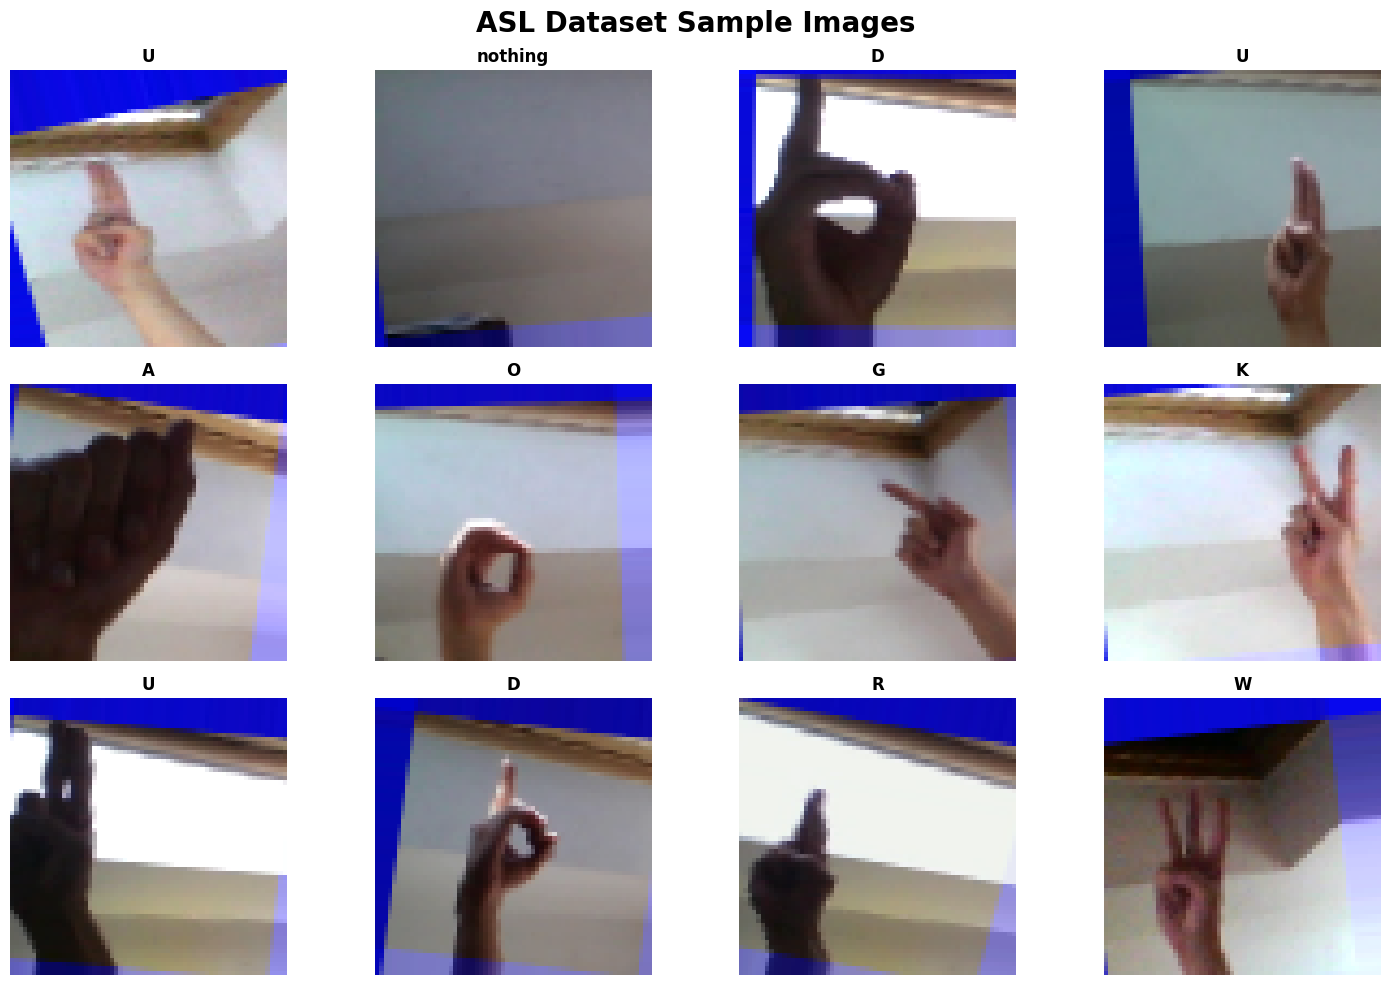

In [12]:
# 🖼 Visualize sample images from dataset

images, labels = next(train_generator)

plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    plt.title(class_names[class_index], fontsize=12, fontweight="bold")

    plt.axis("off")

plt.suptitle("ASL Dataset Sample Images", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

# 🧠 CNN Model Architecture

CNN was selected because it works well with image classification.

The model learns:

- hand shapes
- finger positions
- edges
- gesture patterns
- visual features

In [19]:
# 🧠 Build CNN model for ASL image classification

model = Sequential([

    # First convolution block
    Conv2D(32, (3, 3), activation="relu", input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),

    # Second convolution block
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Third convolution block
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Fourth convolution block
    Conv2D(256, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Convert feature maps into one vector
    Flatten(),

    # Fully connected layer
    Dense(128, activation="relu"),

    # Dropout helps prevent overfitting
    Dropout(0.5),

    # Output layer for 29 classes
    Dense(num_classes, activation="softmax")
])

In [24]:
# ⚡ Compile the CNN model

model.compile(
    optimizer="adam",                  # Adam optimizer is effective for deep learning
    loss="categorical_crossentropy",   # Used for multi-class classification
    metrics=["accuracy"]               # Accuracy is used as main metric
)

# 📋 Show model structure
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523,357 (2.00 MB)

 Trainable params: 523,357 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 📁 Create folders for saving model and results

os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

In [26]:
# 🚀 Train the CNN model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 209s 94ms/step - accuracy: 0.5198 - loss: 1.5457 - val_accuracy: 0.7178 - val_loss: 0.9497
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 203s 93ms/step - accuracy: 0.8461 - loss: 0.4489 - val_accuracy: 0.7884 - val_loss: 0.6910
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 206s 95ms/step - accuracy: 0.9106 - loss: 0.2648 - val_accuracy: 0.8224 - val_loss: 0.6521
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 206s 95ms/step - accuracy: 0.9383 - loss: 0.1878 - val_accuracy: 0.8396 - val_loss: 0.6470
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 201s 92ms/step - accuracy: 0.9507 - loss: 0.1530 - val_accuracy: 0.8617 - val_loss: 0.5643
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 200s 92ms/step - accuracy: 0.9601 - loss: 0.1270 - val_accuracy: 0.8460 - val_loss: 0.6770
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 207s 95ms/step - accuracy: 0.9668 - loss: 0.1093 - val_accuracy: 0.8487 - val_loss: 0.6107
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 199s 92ms/step - accuracy: 

In [27]:
# 💾 Save the trained CNN model

os.makedirs("/content/models", exist_ok=True)

model.save("/content/models/asl_cnn_final_model.h5")

print("Model saved successfully.")

Model saved successfully.


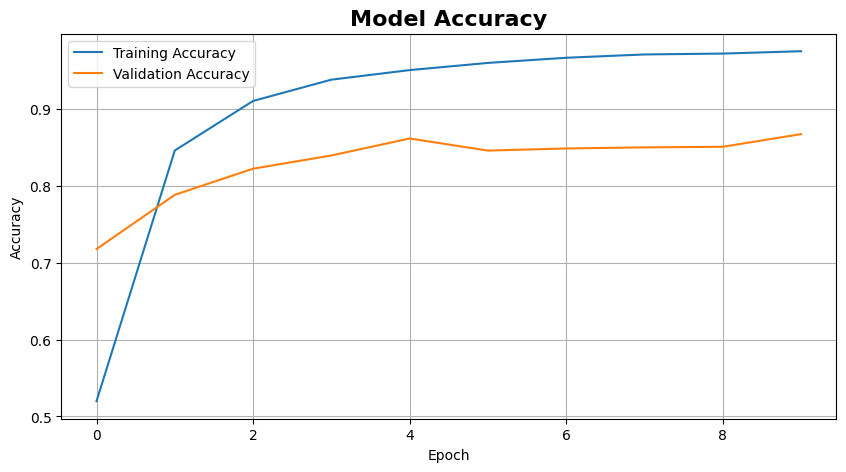

In [28]:
# 📈 Plot training and validation accuracy

os.makedirs("/content/results", exist_ok=True)

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.savefig("/content/results/accuracy_plot.png")
plt.show()

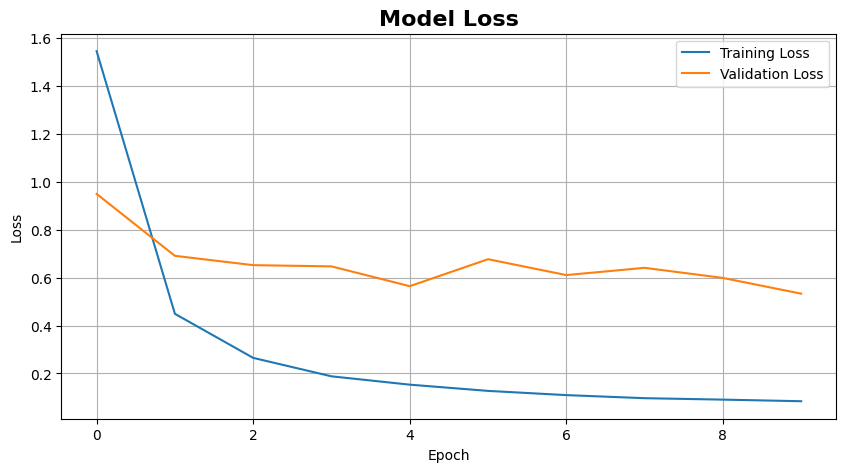

In [29]:
# 📉 Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.savefig("/content/results/loss_plot.png")
plt.show()

In [30]:
# 📊 Evaluate the trained model on validation data

val_loss, val_accuracy = model.evaluate(validation_generator)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.8680 - loss: 0.5216
Validation Accuracy: 0.8680
Validation Loss: 0.5216


In [31]:
# 🔍 Generate predictions for validation data

predictions = model.predict(validation_generator)

# Predicted class labels
y_pred = np.argmax(predictions, axis=1)

# True class labels
y_true = validation_generator.classes

print("Predictions generated successfully.")

544/544 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step
Predictions generated successfully.


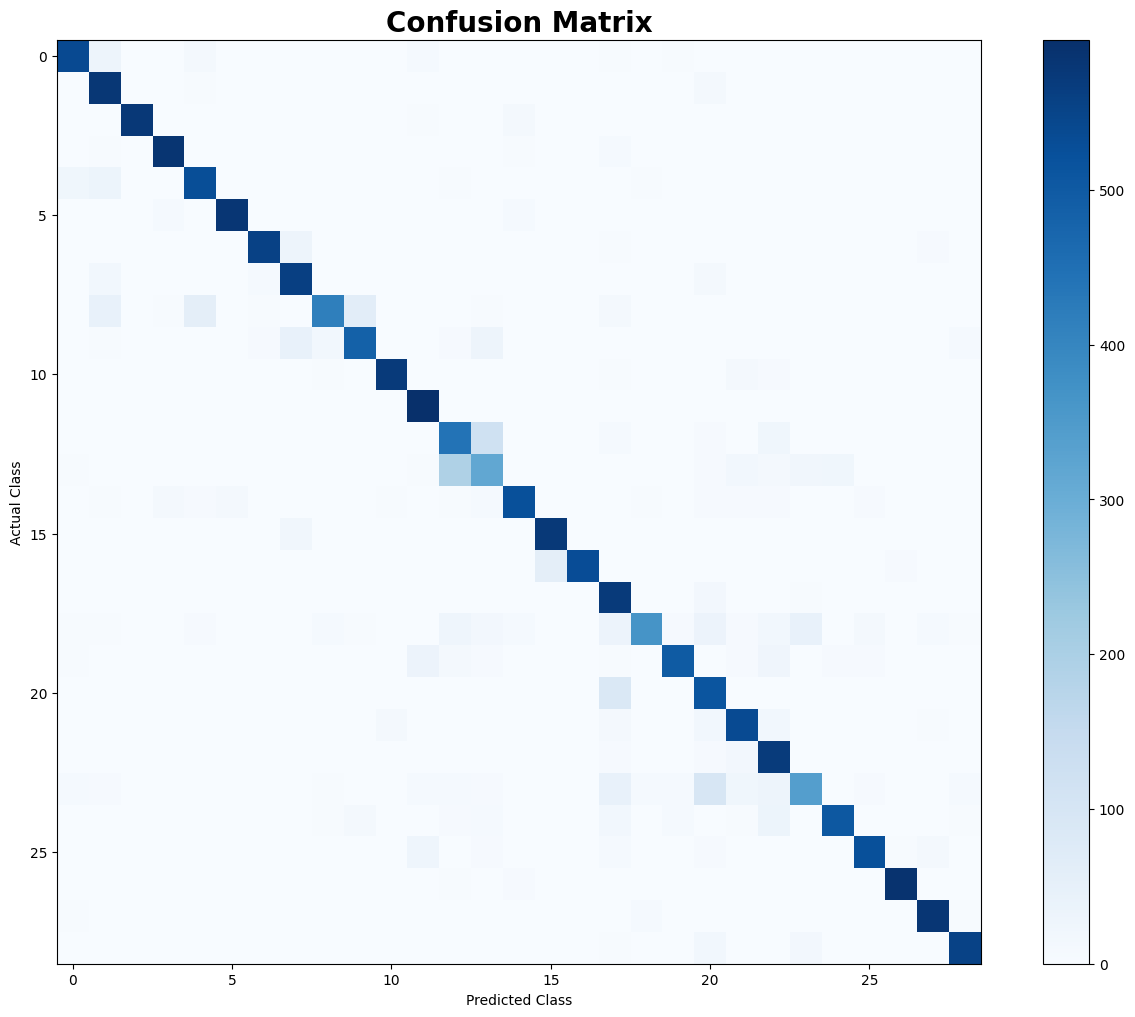

In [32]:
# 📌 Create and visualize confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 12))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix", fontsize=20, fontweight="bold")
plt.colorbar()

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.savefig("/content/results/confusion_matrix.png")
plt.show()

In [33]:
# 📄 Generate classification report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

           A       0.91      0.90      0.90       600
           B       0.80      0.97      0.87       600
           C       0.99      0.96      0.98       600
           D       0.96      0.97      0.97       600
           E       0.86      0.88      0.87       600
           F       0.97      0.97      0.97       600
           G       0.97      0.93      0.95       600
           H       0.86      0.94      0.90       600
           I       0.91      0.69      0.78       600
           J       0.86      0.81      0.83       600
           K       0.97      0.95      0.96       600
           L       0.87      0.99      0.93       600
           M       0.63      0.74      0.68       600
           N       0.61      0.53      0.56       600
           O       0.92      0.87      0.90       600
           P       0.91      0.96      0.93       600
           Q       0.99      0.89      0.94       600
           R       0.69    

In [34]:
# 📊 Convert classification report into a table

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
A,0.913265,0.895000,0.904040,600.000000
B,0.797799,0.966667,0.874152,600.000000
C,0.994828,0.961667,0.977966,600.000000
D,0.958949,0.973333,0.966088,600.000000
E,0.861338,0.880000,0.870569,600.000000
F,0.971619,0.970000,0.970809,600.000000
G,0.965278,0.926667,0.945578,600.000000
H,0.861751,0.935000,0.896882,600.000000
I,0.907895,0.690000,0.784091,600.000000
J,0.859680,0.806667,0.832330,600.000000


In [35]:
# 📈 Compare final training and validation accuracy

train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]

train_loss = history.history["loss"][-1]
val_loss_final = history.history["val_loss"][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Training Loss: {train_loss:.4f}")
print(f"Final Validation Loss: {val_loss_final:.4f}")

difference = train_acc - val_acc

print(f"Accuracy Difference: {difference:.4f}")

Final Training Accuracy: 0.9753
Final Validation Accuracy: 0.8674
Final Training Loss: 0.0838
Final Validation Loss: 0.5331
Accuracy Difference: 0.1079


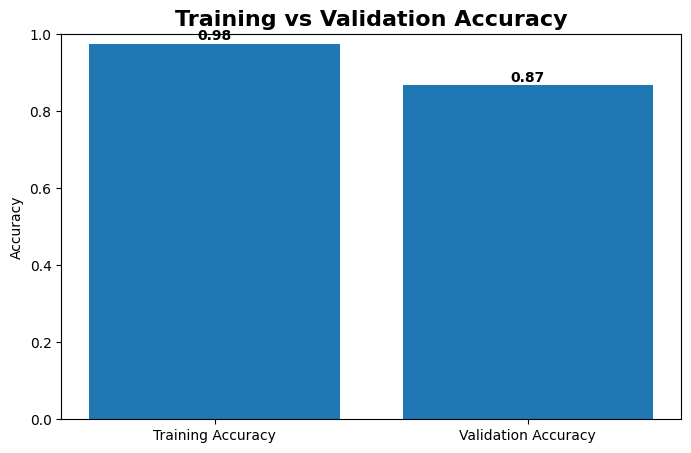

In [36]:
# 📊 Visual comparison of training and validation accuracy

metrics = ["Training Accuracy", "Validation Accuracy"]
values = [train_acc, val_acc]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, values)

plt.ylim(0, 1)

plt.title("Training vs Validation Accuracy", fontsize=16, fontweight="bold")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.show()

# 🔍 Overfitting Analysis

Training accuracy and validation accuracy were compared to check model generalization.

If training accuracy is much higher than validation accuracy, the model may be overfitting.

In this project, data augmentation and dropout were used to reduce overfitting and improve generalization.

# 📌 Evaluation Metrics Explanation

Accuracy shows the overall percentage of correct predictions.

Precision shows how many predicted classes were correct.

Recall shows how many real class examples were correctly found.

F1-score is the balance between precision and recall.

The confusion matrix helps identify which ASL classes are confused with each other.

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


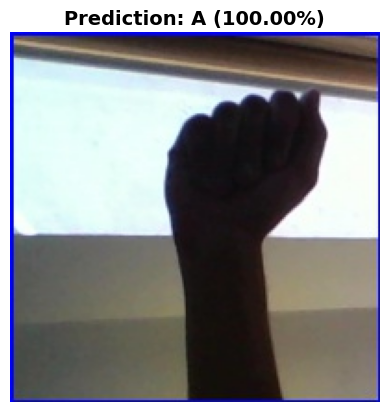

Predicted Class: A
Confidence: 100.00%


In [37]:
# 🤖 Test model on one ASL image

test_image_path = "/content/asl_alphabet/asl_alphabet_test/asl_alphabet_test/A_test.jpg"

img = Image.open(test_image_path).convert("RGB")

img_resized = img.resize((64, 64))

img_array = np.array(img_resized) / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class} ({confidence:.2f}%)",
    fontsize=14,
    fontweight="bold"
)
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

# 🌐 Streamlit Web Application

A Streamlit application was developed to make the project interactive.

The application allows users to:

- upload ASL gesture images;
- run prediction using the trained CNN model;
- view the predicted ASL letter;
- see the prediction confidence.

The app was tested locally using:

```bash
streamlit run app.py


---

## TEXT CELL — Final Results

```markdown
# 🏆 Final Results

The project successfully demonstrates a complete deep learning pipeline:

```text
Dataset → Preprocessing → Data Augmentation → CNN Training → Evaluation → Prediction → Streamlit App


---

## TEXT CELL — Final Conclusion

```markdown
# ✅ Final Conclusion

This project demonstrated how deep learning and computer vision can be used for accessibility technologies.

A CNN-based model was trained to recognize American Sign Language hand gestures from images.

The project helped improve practical understanding of:

- image preprocessing;
- data augmentation;
- CNN model building;
- model training;
- model evaluation;
- prediction testing;
- Streamlit application development.

Future improvements may include:

- real-time webcam recognition;
- online deployment;
- larger dataset;
- transfer learning;
- mobile application support.

In [42]:
# 📥 Download final model and result images

from google.colab import files

files.download("/content/models/asl_cnn_final_model.h5")
files.download("/content/results/accuracy_plot.png")
files.download("/content/results/loss_plot.png")
files.download("/content/results/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>